In [93]:
import alphastats

In [94]:
diann_data = alphastats.DIANNLoader(file="diann_output.pg_matrix.tsv")

In [139]:
dataset = alphastats.DataSet(
    loader = diann_data, 
    metadata_path="metadata_alphastats.xlsx", 
    sample_column="sample_id"
)

DataSet has been created.
Attributes of the DataSet can be accessed using: 
DataSet.rawinput:	 Raw Protein data.
DataSet.mat:		Processed data matrix with ProteinIDs/ProteinGroups as columns and samples as rows. All computations are performed on this matrix.
DataSet.metadata:	Metadata for the samples in the matrix. Metadata will be matched with DataSet.mat when needed (for instance Volcano Plot).


In [140]:
dataset.metadata


,sample_id,biological_id,grouping
0,2ul_CG_3.mzML,vcam1-ip-r1,vcam1-ip
1,2ul_CG_4.mzML,vcam1-igg-r1,vcam1-igg
2,2ul_CG_5.mzML,vcam1-ip-r2,vcam1-ip
3,2ul_CG_6.mzML,vcam1-igg-r2,vcam1-igg
4,2ul_CG_7.mzML,vcam1-ip-r3,vcam1-ip
5,2ul_CG_8.mzML,vcam1-igg-r3,vcam1-igg
6,2ul_CG_9.mzML,vcam1-ip-r4,vcam1-ip
7,2ul_CG_10.mzML,vcam1-igg-r4,vcam1-igg


In [141]:
dataset.preprocess(
    remove_contaminations=True,
    normalization = "zscore",
    imputation = "knn"
)

Data has been log2-transformed.


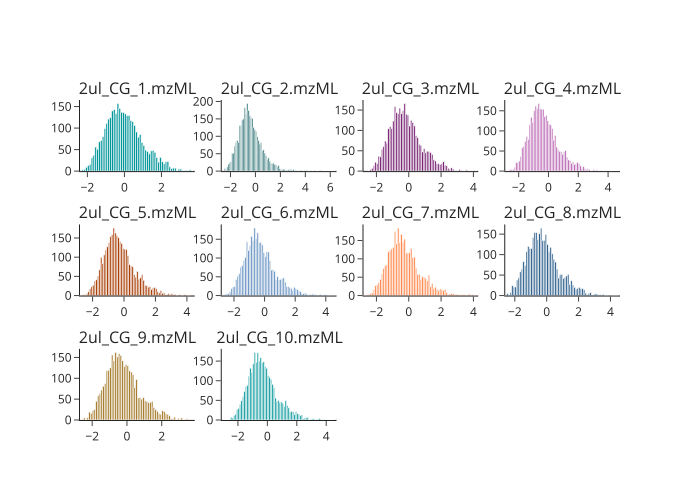

In [148]:
plot = dataset.plot_samplehistograms()
plot.show(renderer = "svg")

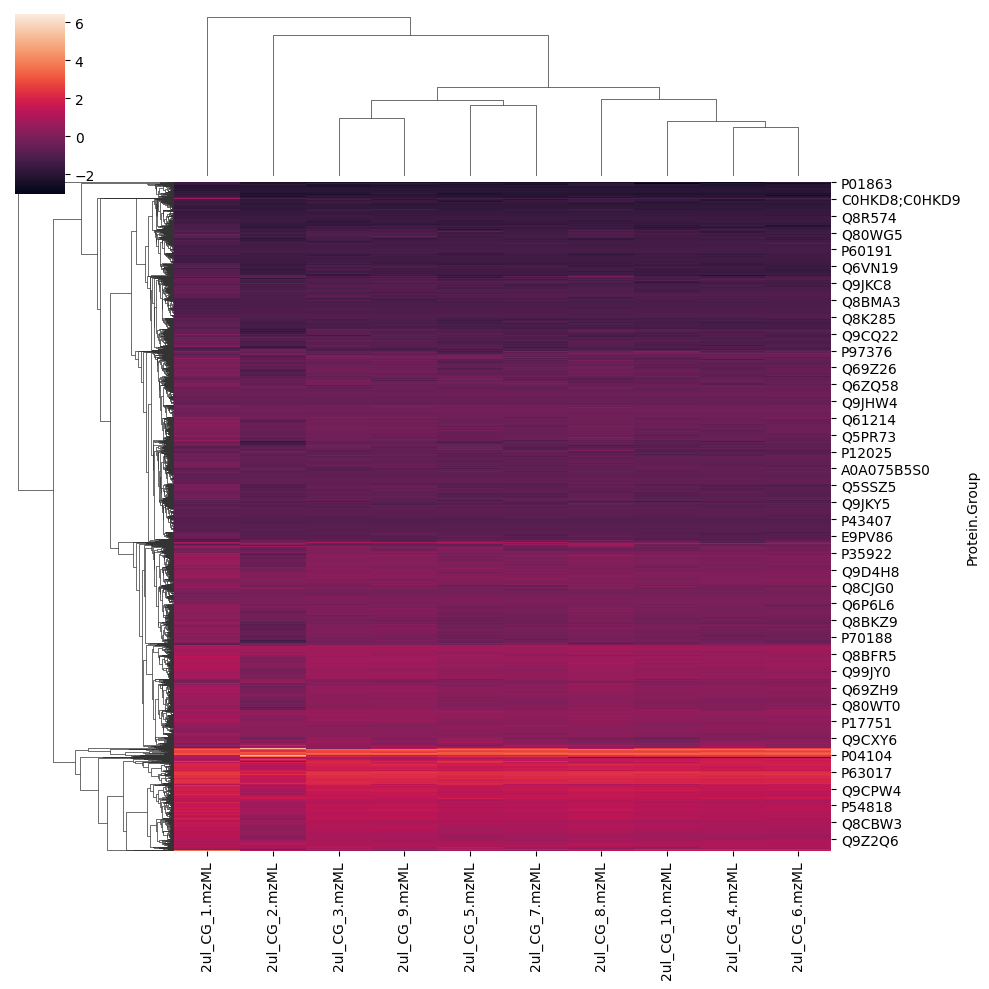

In [153]:
plot = dataset.plot_clustermap()


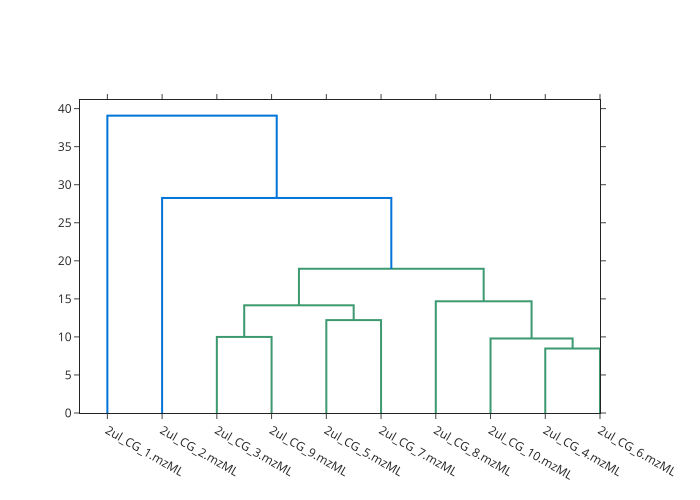

In [152]:
plot = dataset.plot_dendrogram()
plot.show(renderer = "svg")

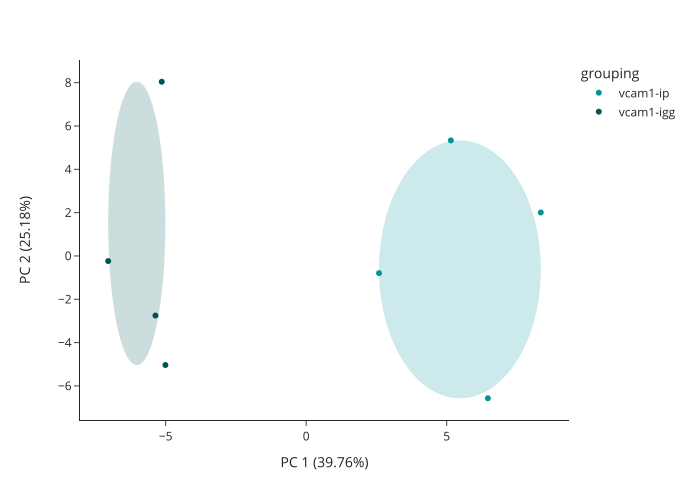

In [142]:
plot = dataset.plot_pca(group = "grouping", circle = True)
plot.show(renderer = "svg")

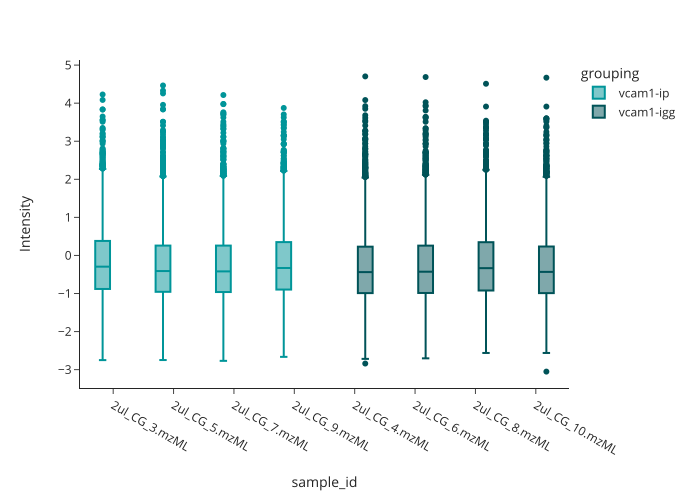

In [143]:
plot = dataset.plot_sampledistribution(color = "grouping", method="box", log_scale=False)
plot.show(renderer = "svg")

In [144]:
plot = dataset.plot_volcano(column = "grouping", group1 = "vcam1-igg", group2 = "vcam1-ip")
plot.plotting_data

Calculating Students t-test...


,Protein.Group,pval,log2fc,-log10(p-value),color
0,A0A075B5L5;A0A0B4J1I5;A0A0B4J1I8,0.398917,-0.062196,0.399117,non_sig
1,A0A075B5M7,0.695766,-0.098244,0.157537,non_sig
2,A0A075B5M9,0.609013,-0.008791,0.215374,non_sig
3,A0A075B5N3,0.004407,0.640086,2.355831,non_sig
4,A0A075B5N5,0.000194,-0.895112,3.711134,non_sig
...,...,...,...,...,...
3488,Q9Z321,0.843827,-0.016389,0.073747,non_sig
3489,Q9Z329,0.006866,-0.172277,2.163320,non_sig
3490,Q9Z351,0.650335,-0.042263,0.186863,non_sig
3491,S4R1M9,0.789126,0.045340,0.102854,non_sig


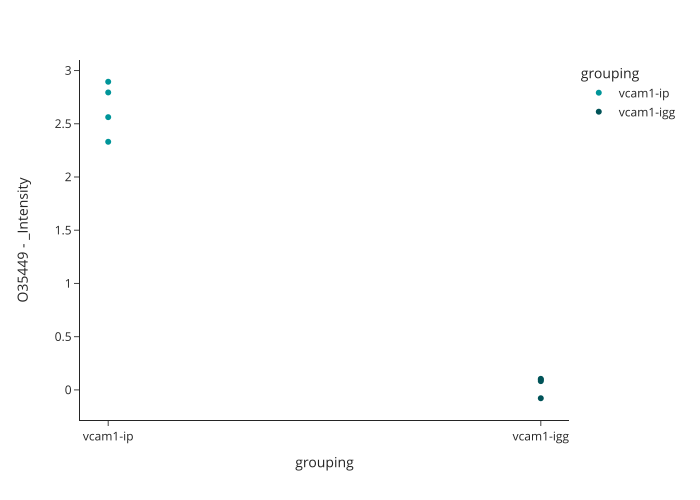

In [146]:
plot = dataset.plot_intensity(protein_id="O35449", group = "grouping", method = "scatter")
plot.show(renderer = "svg")